# NB3 — Supply-Network Graph

**Scope.** Produces one consumer parquet for the convergence layer:
- `outputs/nb3_seller_network_scores.parquet` — per-seller graph metrics (PageRank, in-degree, isolation flag, BFS backup, high-delay PageRank).

**Rubric surface in this notebook.** GraphFrames (vertices = sellers ∪ `customer_unique_id`; edges = purchase + serves) · PageRank · `connectedComponents(algorithm="graphx")` · motif finding `(a)-[]->(c); (b)-[]->(c)` · BFS · induced high-delay subgraph.

**Convergence layer** (merging this parquet with NB1 + NB2 into `seller_risk_index.parquet`) lives in `00_main.ipynb` and `src/olist/pipeline/convergence.py`. This notebook stops at the network-scores write.

**Narrative structure.** This notebook follows the **CRISP-DM** methodology — six sections from *Business Understanding* to *Deployment*. Every code cell calls into `src/olist/pipeline/network.py`; every chart/table goes through `src/olist/viz.py`.

## 0. Boot — `SparkSession` with the GraphFrames jar

In [1]:
import os, sys, inspect
from pathlib import Path

os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@11/libexec/openjdk.jdk/Contents/Home"
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

from olist.spark_session import get_spark
from pyspark.sql import functions as F

spark = get_spark("nb3-supply-network", with_graphframes=True)
spark.sparkContext.setLogLevel("WARN")
print("Spark", spark.version)


:: loading settings :: url = jar:file:/Users/lukas/Desktop/NOVA-IMS_Second_Semester/Big%20Data%20Analysis/.venv/lib/python3.9/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /Users/lukas/.ivy2/cache
The jars for the packages stored in: /Users/lukas/.ivy2/jars
graphframes#graphframes added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-2be7f895-0d91-4995-a0c9-a594e72b3cf8;1.0
	confs: [default]
	found graphframes#graphframes;0.8.3-spark3.5-s_2.12 in spark-packages
	found org.slf4j#slf4j-api;1.7.16 in central
:: resolution report :: resolve 80ms :: artifacts dl 2ms
	:: modules in use:
	graphframes#graphframes;0.8.3-spark3.5-s_2.12 from spark-packages in [default]
	org.slf4j#slf4j-api;1.7.16 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   2   |   0   |   0   |   0   ||   2   |   0   |
	----------------------------------

26/04/24 22:16:38 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


Spark 3.5.8


## 1. Business Understanding

**Why network structure matters to Olist.** Two sellers might ship identical products to the same customer base, but if one is a *structural hub* of the purchase network (many customers, many shared customers with peers), its failure cascades far wider than a peripheral seller's. This notebook builds the **network component** of the Seller Risk Index:

- **Centrality signal.** PageRank on the bidirectional customer-seller graph — how structurally important is each seller?
- **Isolation signal.** Connected-components analysis — sellers sitting alone in a tiny component have no backup if they fail.
- **Contagion signal.** PageRank re-run on the *late-shipping* subgraph — which sellers are central in the part of the network where delays propagate?
- **Resilience signal.** BFS from top-PageRank sellers — what is the nearest alternative seller if this one goes down?

**Stakeholder question.** *"If a seller fails, who else is affected and who can absorb the demand?"* — the per-seller network parquet written in §6 answers this row-by-row.

## 2. Data Understanding

Four source tables combine into the graph: `orders ⋈ order_items ⋈ broadcast(customers) ⋈ broadcast(sellers)`, filtered to *delivered* orders. Vertices are the union of distinct seller IDs and distinct `customer_unique_id`s (not `customer_id` — CLAUDE.md §4); edges carry the item count and average delivery delay.

### 2.1 Order-line base

Each row is one delivered order-item, with its customer and seller attached. Cached to `outputs/_cache/network_order_lines.parquet` via `@step`.

In [2]:
from olist.pipeline.network import build_order_lines

order_lines = build_order_lines(spark)
print(f"order_lines rows: {order_lines.count():,}")
order_lines.limit(3).show(truncate=False)


[cache] run network.order_lines (5.3s, wrote 110196 rows → outputs/_cache/network_order_lines.parquet)
order_lines rows: 110,196


+--------------------------------+--------------------------------+--------------------------------+------------+-------------------+-----+
|order_id                        |customer_unique_id              |seller_id                       |seller_state|delivery_delay_days|price|
+--------------------------------+--------------------------------+--------------------------------+------------+-------------------+-----+
|55c27ec4136ec6d13577c7fb34c62b68|829d6e7a43080e1e26d649f475b9288b|cbd996ad3c1b7dc71fd0e5f5df9087e2|SP          |-17                |35.79|
|55c27ec4136ec6d13577c7fb34c62b68|829d6e7a43080e1e26d649f475b9288b|cbd996ad3c1b7dc71fd0e5f5df9087e2|SP          |-17                |35.79|
|55c27ec4136ec6d13577c7fb34c62b68|829d6e7a43080e1e26d649f475b9288b|cbd996ad3c1b7dc71fd0e5f5df9087e2|SP          |-17                |35.79|
+--------------------------------+--------------------------------+--------------------------------+------------+-------------------+-----+



## 3. Data Preparation

Two transformations build the graph structure itself:

1. **Vertex set.** Distinct union of seller IDs and `customer_unique_id`s, tagged with a `type` column. Using `customer_unique_id` (not `customer_id`) ensures a returning customer is one vertex, not many — motifs and BFS depend on this.
2. **Edge set.** For every distinct `(customer, seller)` pair we emit one `purchase` edge (c→s) and one `serves` edge (s→c). Bidirectionality is required so PageRank flows both ways and BFS can reach *other sellers* via shared customers.

### 3.1 Vertices — sellers ∪ unique customers

In [3]:
from olist.pipeline.network import build_vertices

vertices = build_vertices(spark)
print(f"vertices total: {vertices.count():,}")
vertices.groupBy("type").agg(F.count("*").alias("n")).orderBy("type").show()


[cache] run network.vertices (1.1s, wrote 96326 rows → outputs/_cache/network_vertices.parquet)
vertices total: 96,326


+--------+-----+
|    type|    n|
+--------+-----+
|customer|93356|
|  seller| 2970|
+--------+-----+



### 3.2 Edges — bidirectional `purchase` + `serves`

In [4]:
from olist.pipeline.network import build_edges

edges = build_edges(spark)
print(f"edges total: {edges.count():,}")
edges.groupBy("edge_type").agg(F.count("*").alias("n")).orderBy("edge_type").show()


[cache] run network.edges (0.9s, wrote 193788 rows → outputs/_cache/network_edges.parquet)
edges total: 193,788
+---------+-----+
|edge_type|    n|
+---------+-----+
| purchase|96894|
|   serves|96894|
+---------+-----+



## 4. Modeling

Five GraphFrame algorithms, each its own `@step` so reruns on unchanged inputs skip the expensive compute.

### 4.1 GraphFrame + per-seller degree stats

`GraphFrame(vertices, edges)` is cheap to reconstruct — only the algorithms below are cached.

In [5]:
from olist.pipeline.network import build_graph_frame, seller_degree_stats

g = build_graph_frame(spark)
print("GraphFrame:", g)

seller_degrees = seller_degree_stats(spark)
print("\nTop 5 sellers by purchase-only in-degree:")
seller_degrees.orderBy(F.col("in_degree_purchase_only").desc()).limit(5).show()


GraphFrame: GraphFrame(v:[id: string, type: string], e:[src: string, dst: string ... 3 more fields])



Top 5 sellers by purchase-only in-degree:


+--------------------+------+---------------+-----------------------+
|                  id|  type|in_degree_total|in_degree_purchase_only|
+--------------------+------+---------------+-----------------------+
|6560211a19b47992c...|seller|           1790|                   1790|
|4a3ca9315b744ce9f...|seller|           1759|                   1759|
|cc419e0650a3c5ba7...|seller|           1607|                   1607|
|1f50f920176fa81da...|seller|           1383|                   1383|
|da8622b14eb17ae28...|seller|           1272|                   1272|
+--------------------+------+---------------+-----------------------+



### 4.2 PageRank — seller centrality in the bidirectional graph

`resetProbability=0.15, maxIter=10`. Cached to `outputs/_cache/network_pagerank.parquet`. Projected to seller vertices only and renamed `pagerank_score`.

In [6]:
from olist.pipeline.network import compute_pagerank

seller_pagerank = compute_pagerank(spark)
print(f"seller_pagerank rows: {seller_pagerank.count():,}")


[cache] run network.pagerank (15.8s, wrote 2970 rows → outputs/_cache/network_pagerank.parquet)
seller_pagerank rows: 2,970


### 4.3 Connected components — isolated-seller flag

Uses `algorithm="graphx"`. The default message-passing variant OOMs the JVM heap on ~100k vertices at 6g driver memory (see `decisions_log.md` 2026-04-22 NB3 entry). Sellers sitting in a component of size 1 are flagged `is_isolated = 1`.

In [7]:
from olist.pipeline.network import compute_connected_components

cc_with_size = compute_connected_components(spark)
isolated_sellers = cc_with_size.filter(
    (F.col("type") == "seller") & (F.col("component_size") == 1)
)
print(f"isolated sellers: {isolated_sellers.count():,}")
print(f"distinct components: {cc_with_size.select('component').distinct().count():,}")


26/04/24 22:17:05 WARN CacheManager: Asked to cache already cached data.


26/04/24 22:17:10 WARN BlockManager: Block rdd_478_3 already exists on this machine; not re-adding it
26/04/24 22:17:10 WARN BlockManager: Block rdd_478_1 already exists on this machine; not re-adding it


26/04/24 22:17:17 WARN BlockManager: Block rdd_672_3 already exists on this machine; not re-adding it
26/04/24 22:17:17 WARN BlockManager: Block rdd_672_1 already exists on this machine; not re-adding it


26/04/24 22:17:18 WARN BlockManager: Block rdd_704_3 already exists on this machine; not re-adding it
26/04/24 22:17:18 WARN BlockManager: Block rdd_704_2 already exists on this machine; not re-adding it


[cache] run network.connected_components (15.1s, wrote 96326 rows → outputs/_cache/network_connected_components.parquet)
isolated sellers: 0
distinct components: 1,655


### 4.4 Motif — shared-customer seller pairs `(a)-[]->(c); (b)-[]->(c)`

Two sellers `a` and `b` sharing a customer `c` via two `serves` edges. Deduped with `a.id < b.id`. Captures the "product substitutability" relation — if `a` fails, `b` already serves many of `a`'s customers.

In [8]:
from olist.pipeline.network import compute_shared_customer_motifs

shared_customer_pairs = compute_shared_customer_motifs(spark)
print(f"distinct seller-pairs sharing ≥1 customer: {shared_customer_pairs.count():,}")


[cache] run network.motifs_shared_customers (1.0s, wrote 3383 rows → outputs/_cache/network_motifs.parquet)
distinct seller-pairs sharing ≥1 customer: 3,383


### 4.5 BFS — backup seller for each top-10 PageRank seller

Per-seed BFS with `maxPathLength=3`; first hit other than self is the backup. Flagged `TOP10_PAGERANK_DRIVER` (10-row driver list) and `BFS_BACKUP_COLLECT` (≤1 row per BFS call) — both capped by construction.

In [9]:
from olist.pipeline.network import compute_bfs_backups

backup_df = compute_bfs_backups(spark)
backup_df.show(truncate=False)


[cache] run network.bfs_backups (17.2s, wrote 10 rows → outputs/_cache/network_bfs_backups.parquet)
+--------------------------------+--------------------------------+
|seller_id                       |backup_seller_id                |
+--------------------------------+--------------------------------+
|da8622b14eb17ae2831f4ac5b9dab84a|b64d51f0435e884e8de603b1655155ae|
|7a67c85e85bb2ce8582c35f2203ad736|c4fb51fb1c5b7c07bc5e67be6e7e8f6e|
|cc419e0650a3c5ba77189a1882b7556a|2e1c9f22be269ef4643f826c9e650a52|
|6560211a19b47992c3666cc44a7e94c0|6562efe88ce0826a4ca4f189f03b4b84|
|4a3ca9315b744ce9f8e9374361493884|6560211a19b47992c3666cc44a7e94c0|
|4869f7a5dfa277a7dca6462dcf3b52b2|ef506c96320abeedfb894c34db06f478|
|1f50f920176fa81dab994f9023523100|1025f0e2d44d7041d6cf58b6550e0bfa|
|955fee9216a65b617aa5c0531780ce60|b1ac6ea7895bc3dd6f0f6f4abbdd2821|
|ea8482cd71df3c1969d7b9473ff13abc|8160255418d5aaa7dbdc9f4c64ebda44|
|3d871de0142ce09b7081e2b9d1733cb1|bdb3edbaee43a761e2d4f258dc08f348|
+---------------

### 4.6 High-delay subgraph — PageRank of the late-shipping graph

Induced subgraph over edges with `avg_delay > 5`; PageRank there identifies sellers that are structurally central to *late* shipments — i.e. the contagion risk.

In [10]:
from olist.pipeline.network import compute_delayed_subgraph_pagerank

seller_network_risk = compute_delayed_subgraph_pagerank(spark)
print(f"seller_network_risk rows: {seller_network_risk.count():,}")


[cache] run network.delayed_pagerank (3.2s, wrote 961 rows → outputs/_cache/network_delayed_pagerank.parquet)
seller_network_risk rows: 961


## 5. Evaluation

Three diagnostic views: top-10 PageRank sellers (styled), top-20 shared-customer motifs (styled), and component-size distribution.

### 5.1 Top-10 sellers by PageRank

These are the network's structural hubs. A failure at any of these cascades widely — they are the first candidates for proactive monitoring regardless of their demand/sentiment scores.

In [11]:
from olist import viz

# BIG-DATA-SAFETY-ESCAPE: PANDAS_MATPLOTLIB_VIZ — capped to 10 rows
top10_pagerank = (
    seller_pagerank.withColumnRenamed("id", "seller_id")
    .orderBy(F.col("pagerank_score").desc())
    .limit(10)
    .toPandas()
)
top10_pagerank["seller_id"] = top10_pagerank["seller_id"].str.slice(0, 10) + "…"
viz.styled_topn_table(
    top10_pagerank,
    bar_cols=["pagerank_score"],
    fmt={"pagerank_score": "{:.4f}"},
    title="Top-10 sellers by PageRank (bidirectional graph)",
)


seller_id,pagerank_score
6560211a19…,643.4932
4a3ca9315b…,610.6292
cc419e0650…,580.4102
1f50f92017…,493.8027
955fee9216…,458.0732
da8622b14e…,454.5277
7a67c85e85…,410.9353
4869f7a5df…,405.2516
ea8482cd71…,404.6859
3d871de014…,383.7964


### 5.2 Top-20 seller pairs by shared customers

Substitutability signal: these pairs are the strongest candidate backup relationships in the marketplace. A high shared-customer count implies one seller can absorb the other's demand with minimal customer friction.

In [12]:
# BIG-DATA-SAFETY-ESCAPE: PANDAS_MATPLOTLIB_VIZ — capped to 20 rows
top20_motifs = (
    shared_customer_pairs.orderBy(F.col("n_shared_customers").desc())
    .limit(20)
    .toPandas()
)
top20_motifs["seller_a"] = top20_motifs["seller_a"].str.slice(0, 10) + "…"
top20_motifs["seller_b"] = top20_motifs["seller_b"].str.slice(0, 10) + "…"
viz.styled_topn_table(
    top20_motifs,
    bar_cols=["n_shared_customers"],
    fmt={"n_shared_customers": "{:d}"},
    title="Top-20 seller pairs by shared customers (motif `(a)->c<-(b)`)",
)


seller_a,seller_b,n_shared_customers
4a3ca9315b…,cca3071e3e…,20
1835b56ce7…,1900267e84…,16
1025f0e2d4…,1f50f92017…,16
4a3ca9315b…,d1c281d3ae…,15
391fc6631a…,4a3ca9315b…,14
4a3ca9315b…,dc4a0fc896…,11
88460e8ebd…,f457c46070…,11
6973a06f48…,f457c46070…,10
4a3ca9315b…,d2374cbcbb…,10
4a3ca9315b…,d20b021d3e…,9


### 5.3 Component-size distribution

How fragmented is the marketplace? If almost every seller sits in one giant component, the graph is well-connected and isolation-risk is low; if many components of size 1 exist, those sellers have no structural redundancy.

+--------+------------+
|size_bin|n_components|
+--------+------------+
|     5–9|         404|
|   10–99|         339|
|    100+|           2|
|     2–4|         910|
+--------+------------+



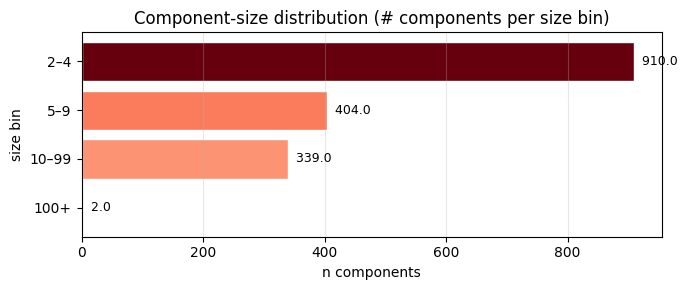

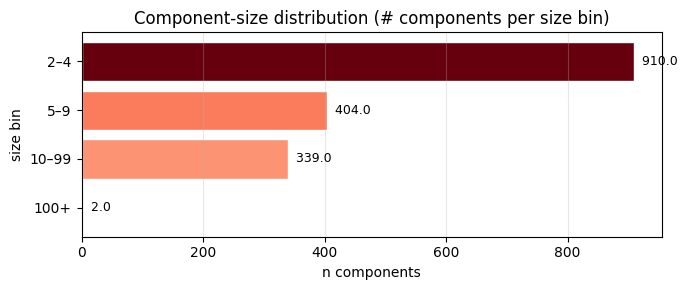

In [13]:
from olist.pipeline.network import component_size_histogram

# BIG-DATA-SAFETY-ESCAPE: PANDAS_MATPLOTLIB_VIZ — 5-row aggregate
hist = component_size_histogram(spark)
hist.show()

bin_order = ["1 (isolated)", "2–4", "5–9", "10–99", "100+"]
hist_pd = hist.toPandas()
hist_pd["size_bin"] = hist_pd["size_bin"].astype("category").cat.set_categories(bin_order, ordered=True)
hist_pd = hist_pd.sort_values("size_bin")
viz.state_bar(
    hist_pd,
    value_col="n_components",
    label_col="size_bin",
    title="Component-size distribution (# components per size bin)",
    sort="asc",
    color_by_value=True,
)


## 6. Deployment

The deployable artefact is `outputs/nb3_seller_network_scores.parquet` — one row per seller, six columns, consumed directly by the convergence layer (`olist.pipeline.convergence.build_seller_risk_index`).

### 6.1 Per-seller network scores

Columns: `seller_id`, `pagerank_score`, `in_degree`, `is_isolated`, `backup_seller_id`, `network_risk_score` (high-delay-subgraph PageRank).

In [14]:
from olist.pipeline.network import build_seller_network_scores

seller_network_scores = build_seller_network_scores(spark)
print(f"seller_network_scores rows: {seller_network_scores.count():,}")
seller_network_scores.groupBy("is_isolated").agg(F.count("*").alias("n")).orderBy("is_isolated").show()


[cache] run network.seller_scores (0.8s, wrote 2970 rows → outputs/nb3_seller_network_scores.parquet)
seller_network_scores rows: 2,970
+-----------+----+
|is_isolated|   n|
+-----------+----+
|          0|2970|
+-----------+----+



### 6.2 Top-10 by delayed-subgraph PageRank — deployment-ready table

These are the "contagion hubs": sellers central to the part of the network where deliveries arrive late. An account manager should prioritise these for operational review — any service improvement here has network-wide spillover.

In [15]:
# BIG-DATA-SAFETY-ESCAPE: PANDAS_MATPLOTLIB_VIZ — capped to 10 rows
top10_risk = (
    seller_network_scores.orderBy(F.col("network_risk_score").desc()).limit(10).toPandas()
)
top10_risk["seller_id"] = top10_risk["seller_id"].str.slice(0, 10) + "…"
top10_risk["backup_seller_id"] = (
    top10_risk["backup_seller_id"].fillna("—").astype(str).str.slice(0, 10) + "…"
)
viz.styled_topn_table(
    top10_risk,
    bar_cols=["network_risk_score"],
    gradient_cols=["pagerank_score"],
    fmt={
        "pagerank_score": "{:.4f}",
        "network_risk_score": "{:.4f}",
        "in_degree": "{:d}",
        "is_isolated": "{:d}",
    },
    title="Top-10 sellers by delayed-subgraph PageRank (network contagion risk)",
)


seller_id,pagerank_score,in_degree,is_isolated,backup_seller_id,network_risk_score
4a3ca9315b…,610.6292,1759,0,6560211a19…,43.1907
4869f7a5df…,405.2516,1117,0,ef506c9632…,29.4133
1f50f92017…,493.8027,1383,0,1025f0e2d4…,27.1993
7c67e1448b…,349.5266,962,0,—…,19.7063
ea8482cd71…,404.6859,1119,0,8160255418…,19.4502
7d13fca152…,201.9996,557,0,—…,18.3432
da8622b14e…,454.5277,1272,0,b64d51f043…,17.4120
06a2c3af7b…,140.3060,385,0,—…,16.8672
8b321bb669…,335.3535,925,0,—…,16.4982
6560211a19…,643.4932,1790,0,6562efe88c…,16.1291


### 6.3 Clean up

In [16]:
ROOT_OUT = Path.cwd().parent / "outputs" if Path.cwd().name == "notebooks" else Path.cwd() / "outputs"
print("Notebook 3 outputs:")
for path in sorted(ROOT_OUT.glob("nb3_*.parquet")):
    print(" ", path.name)
spark.stop()
print("\nSpark stopped.")


Notebook 3 outputs:
  nb3_seller_network_scores.parquet



Spark stopped.
